In [1]:
import numpy as np
import matplotlib.pyplot as plt
import math
import joblib
import torch
import torch.nn as nn
import torchvision
import deepRD.tools.trajectoryTools as trajectoryTools
from torch.utils.data import Dataset, DataLoader
from torch import optim
from tqdm import tqdm
from sklearn.preprocessing import StandardScaler
from scipy.stats import gaussian_kde

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
class MLP(nn.Module):
    def __init__(self, in_dim, out_dim, hidden=(128,128)):
        super().__init__()
        layers, d = [], in_dim
        for h in hidden:
            layers += [nn.Linear(d, h), nn.SiLU(), nn.LayerNorm(h)]
            d = h
        layers += [nn.Linear(d, out_dim)]
        self.net = nn.Sequential(*layers)
    def forward(self, x): return self.net(x)

def reparam(mu, logvar, Tz=1.0):
    eps = torch.randn_like(mu)
    return mu + eps * torch.exp(0.5 * logvar) * Tz

class DiagGaussianHead(nn.Module):
    """Outputs (mu, log_sigma) for R^3."""
    def __init__(self, in_dim, out_dim):
        super().__init__()
        self.mlp = MLP(in_dim, out_dim, hidden=(128,128))
    def forward(self, x):
        out = self.mlp(x)
        mu, log_sig = out[..., :3], out[..., 3:]
        return mu, log_sig

# ---------- CVAE ----------
class CVAE(nn.Module):
    def __init__(self, idim=3, zdim=3, cond_type="piri"):
        super().__init__()
        
        assert cond_type in ("piri", "piririm", "pipimri")
        self.cond_type = cond_type
        self.idim, self.zdim = idim, zdim
        
        if cond_type == "piri":
            self.cdim = 6
        elif cond_type in ("piririm", "pipimri"):
            self.cdim = 9
        
        # networks
        self.encoder = MLP(idim + self.cdim, out_dim=2*zdim, hidden=(128,128))
        self.prior   = MLP(self.cdim, out_dim=2*zdim, hidden=(128,128))
        self.decoder = DiagGaussianHead(zdim + self.cdim, 2*idim)
        
        # normalisers
        self.scaler_r = None
        self.scaler_c = None
        
    def attach_normalizers(self, scaler_r, scaler_c):
        """Attach normalization scalers for automatic preprocessing."""
        self.scaler_r = scaler_r
        self.scaler_c = scaler_c

    def encode(self, r_next, c):
        q = self.encoder(torch.cat([r_next, c], dim=-1))
        q_mu, q_logv = q.split(self.zdim, dim=-1)
        return q_mu, q_logv

    def prior_params(self, c):
        p = self.prior(c)
        p_mu, p_logv = p.split(self.zdim, dim=-1)
        return p_mu, p_logv

    def decode(self, z, c):
        mu, log_sig = self.decoder(torch.cat([z, c], dim=-1))
        return mu, log_sig

    def forward(self, r_next, c):
        p_mu, p_logv = self.prior_params(c)
        q_mu, q_logv = self.encode(r_next, c)
        z = reparam(q_mu, q_logv)
        dec_out = self.decode(z, c)
        return dec_out, (q_mu, q_logv), (p_mu, p_logv)   
    
    # ----- sampling ----- #
    @torch.no_grad()
    def sample_torch(self, c, Tr=1.0, Tz=1.0):
        """
        Sampling from torch tensor, no (de)normalisation.
        """
        p_mu, p_logv = self.prior_params(c)
        z = reparam(p_mu, p_logv, Tz=Tz)  # sample from p(z|c)
        
        mu, log_sig = self.decode(z, c)
        r = mu + torch.exp(log_sig) * torch.randn_like(mu) * Tr
        return r
    
    @torch.no_grad()
    def sample(self, c_n_np, Tr=1.0, Tz=1.0, device=None):
        """
        Sample r_{n+1} in physical units given c_n_np in physical units as NumPy array. 
        Built in normalisation of input and denormalisation of output.

        Args:
            c_n_np (np.ndarray): shape (..., cdim)
            Tr (float): temperature scaling factor for stochasticity
            Tz (float): temperature scaling factor in latent space for stochasticity
            device (torch.device): GPU/CPU device to use (optional)
            
        Handles every conditioning type provided the corresponding scaler.

        Returns:
            np.ndarray: generated r_{n+1} in same physical scale as input
        """
        if device is None:
            device = next(self.parameters()).device

        # ---- Reshape and normalise ---- #
        c_n_np = np.asarray(c_n_np, dtype=np.float32)
        single_sample = False
        if c_n_np.ndim == 1:
            c_n_np = c_n_np.reshape(1, -1)
            single_sample = True
            
        c_norm = self.scaler_c.transform(c_n_np)

        # --- Convert to torch tensor ---
        c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)

        r_next_norm_t = self.sample_torch(c_t, Tr=Tr, Tz=Tz)

        # --- De-normalize to physical scale ---
        r_next_np = r_next_norm_t.cpu().numpy()
        r_next_phys = self.scaler_r.inverse_transform(r_next_np)

        if single_sample:
            r_next_phys = r_next_phys.squeeze()  # (3,)

        return r_next_phys

In [4]:
def gaussian_nll_diag(x, mu, log_sig):
    # x, mu, log_sig: [..., 3]
    # Sum over dims; mean over batch
    return 0.5 * ((x - mu)**2 * torch.exp(-2*log_sig) + 2*log_sig + torch.log(torch.tensor(2*math.pi, device=x.device))).sum(-1).mean()

def kl_diag(q_mu, q_logv, p_mu, p_logv):
    # all [..., zdim]
    # KL(q||p) for diagonal Gaussians; mean over batch
    return 0.5 * (torch.exp(q_logv - p_logv) + (q_mu - p_mu)**2 * torch.exp(-p_logv) - 1 + p_logv - q_logv).sum(-1).mean()

def elbo_loss(r_next, dec_out, q, p, beta=1.0, full_cov=False):
    q_mu, q_logv = q
    p_mu, p_logv = p

    mu, log_sig = dec_out
    nll = gaussian_nll_diag(r_next, mu, log_sig)
    kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
    return nll + beta * kl, nll, kl

def flatten_batch_time(x: torch.Tensor):
    """
    Flatten [B, L, D...] → [B*L, D...]
    Leave [B, D...] unchanged.
    """
    if x.dim() <= 2:
        return x
    # x: [B, L, ...]
    B, L = x.shape[:2]
    return x.reshape(B * L, *x.shape[2:])

In [5]:
def train_cvae(model, train_loader, val_loader=None,
                epochs=50, lr=1e-3, beta_max=1.0, warmup_epochs=10, 
                grad_clip=1.0, save_path=None):

    # Loss history
    train_total, train_nll, train_kl = [], [], []
    val_total = []

    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    scaler = torch.amp.GradScaler('cuda')  # mixed precision
    
    for epoch in range(1, epochs+1):
        
        # ---- KL warm-up scheduler ----
        if epoch <= warmup_epochs:
            beta = beta_max * (epoch / warmup_epochs)
        else:
            beta = beta_max
            
        model.train()
        total_loss, total_nll, total_kl = 0, 0, 0

        loop = tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}")
        for batch in loop:
            # Batch: (r_{n+1}, c_n)
            r_next, c = [x.to(device) for x in batch]
            
            r_next = flatten_batch_time(r_next)
            c = flatten_batch_time(c)
            
            optimizer.zero_grad()
            with torch.amp.autocast('cuda'):
                dec_out, q, p = model(r_next, c)
                q_mu, q_logv = q
                p_mu, p_logv = p
                #ar_mu, p_logv = p
                mu_r, log_sig_r = dec_out

                nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
                kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
                #kl  = kl_diag(q_mu, q_logv, ar_mu, p_logv)
                loss = nll + beta * kl

            scaler.scale(loss).backward()
            if grad_clip is not None:
                scaler.unscale_(optimizer)
                torch.nn.utils.clip_grad_norm_(model.parameters(), grad_clip)
            scaler.step(optimizer)
            scaler.update()
            
            total_loss += loss.item()
            total_nll += nll.item()
            total_kl += kl.item()

            loop.set_postfix(loss=loss.item(), NLL=nll.item(), KL=kl.item())

        scheduler.step()
        print(f"Epoch {epoch}: loss={total_loss/len(train_loader):.4f}, "
              f"NLL={total_nll/len(train_loader):.4f}, KL={total_kl/len(train_loader):.4f}")
        
        train_total.append(total_loss/len(train_loader))
        train_nll.append(total_nll/len(train_loader))
        train_kl.append(total_kl/len(train_loader))
        
        # ---- optional validation ----
        if val_loader is not None and epoch % 5 == 0:
            val_loss = evaluate_cvae(model, val_loader, beta)
            print(f"Validation loss: {val_loss:.4f}")
            val_total.append(val_loss)

        if save_path:
            torch.save({'model_state': model.state_dict()}, save_path)
            
    return {
        "train_total": train_total,
        "train_nll": train_nll,
        "train_kl": train_kl,
        "val_total": val_total,
    }

In [6]:
@torch.no_grad()
def evaluate_cvae(model, loader, beta=1.0):
    model.eval()
    total = 0
    for batch in loader:
        r_next, c = [x.to(device) for x in batch]
        
        r_next = flatten_batch_time(r_next)
        c = flatten_batch_time(c)
        
        dec_out, q, p = model(r_next, c)
        q_mu, q_logv = q
        p_mu, p_logv = p
        mu_r, log_sig_r = dec_out
        nll = gaussian_nll_diag(r_next, mu_r, log_sig_r)
        kl  = kl_diag(q_mu, q_logv, p_mu, p_logv)
        total += (nll + beta*kl).item()
    return total / len(loader)

In [7]:
class RCDataset(Dataset):
    """
    Simple dataset serving (r_next, c) pairs.

    r_next_all : torch.Tensor [N, 3]
    c_all      : torch.Tensor [N, cdim]
    """
    def __init__(self, r_next_all, c_all):
        super().__init__()
        assert isinstance(r_next_all, torch.Tensor)
        assert isinstance(c_all, torch.Tensor)
        assert r_next_all.shape[0] == c_all.shape[0]

        self.r_next = r_next_all
        self.c      = c_all

    def __len__(self):
        return self.r_next.shape[0]

    def __getitem__(self, idx):
        return self.r_next[idx], self.c[idx]

class RVSeqDataset(Dataset):
    """
    Dataset of sliding windows over trajectories of (r_next, c).

    Args
    ----
    r_next_seq : torch.Tensor, shape [N_traj, T, 3]
        r_{n+step} (or whatever you've precomputed per time step)
    c_seq      : torch.Tensor, shape [N_traj, T, cdim]
        conditioning vectors c_n
    L          : int >= 1
        window length (L=1 gives single-step windows)
    step       : int >= 1
        stride between window starts (in time indices)

    Returns
    -------
    __getitem__(idx) -> (r_win, c_win):
        r_win : [L, 3]
        c_win : [L, cdim]
    """
    def __init__(self,
                 r_next_seq: torch.Tensor,
                 c_seq: torch.Tensor,
                 L: int,
                 step: int = 1):
        super().__init__()

        assert isinstance(r_next_seq, torch.Tensor)
        assert isinstance(c_seq, torch.Tensor)
        assert r_next_seq.ndim == 3, "r_next_seq must be [N_traj, T, 3]"
        assert c_seq.ndim == 3, "c_seq must be [N_traj, T, cdim]"
        assert r_next_seq.shape[:2] == c_seq.shape[:2], \
            "r_next_seq and c_seq must match in [N_traj, T]"
        assert L >= 1, "L must be >= 1"
        assert step >= 1, "step must be >= 1"

        self.r_next_seq = r_next_seq       # [N_traj, T, 3]
        self.c_seq      = c_seq            # [N_traj, T, cdim]
        self.L = L
        self.step = step

        self.N_traj, self.T, _ = r_next_seq.shape
        if self.T < L:
            raise ValueError(
                f"Window length L={L} longer than trajectory length T={self.T}."
            )

        # windows start at t = 0, step, 2*step, ..., with t+L-1 < T
        self.windows_per_traj = (self.T - L) // step + 1
        self.total_windows = self.N_traj * self.windows_per_traj

    def __len__(self):
        return self.total_windows

    def __getitem__(self, idx):
        traj_idx = idx // self.windows_per_traj
        win_idx  = idx %  self.windows_per_traj

        t_start = win_idx * self.step
        t_end   = t_start + self.L

        r_win = self.r_next_seq[traj_idx, t_start:t_end, :]   # [L, 3]
        c_win = self.c_seq[traj_idx,  t_start:t_end, :]       # [L, cdim]
        return r_win, c_win

In [79]:
def build_conditioning_and_scalers(q, v, r, cond_type=None, step: int = 1):
    """
    Build (r_next, c) and scalers based on a given conditioning type and time step.

    Args:
        q, v, r : torch tensors of shape [n_traj, n_steps, 3]
        cond_type : str, one of {"piri", "piririm", "pipimri"}
        step : int >= 1
            For step = k, conditioning is at time n and the target is r_{n+k}.
            For piririm / pipimri the "prev" term is at time n-k.

    Returns:
        r_next_all : [N, 3]  flattened r_{n+step}
        c_all      : [N, cdim] flattened conditioning vectors
        scaler_r   : fitted StandardScaler for r_next
        scaler_c   : fitted StandardScaler for conditioning variables
    """
    assert q.shape == v.shape == r.shape
    assert q.ndim == 3 and q.shape[-1] == 3, "Expect (n_traj, n_steps, 3) for q, v, r"
    assert step >= 1, "step must be a positive integer"

    n_traj, T, _ = q.shape
    k = step

    if cond_type == "piri":
        # n = 0 .. T - k - 1
        # r_next = r_{n+k}, v_n = v_n, r_n = r_n
        if T <= k:
            raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piri'.")

        r_next = r[:, k:, :]          # r_{n+k}, indices k .. T-1
        v_n    = v[:, :-k, :]         # v_n,    indices 0 .. T-k-1
        r_n    = r[:, :-k, :]         # r_n,    indices 0 .. T-k-1

        c = torch.cat([v_n, r_n], dim=-1)  # [..., 6]

    elif cond_type == "piririm":
        # Generalisation of:
        #   step=1: r_next = r[:, 2:], v_n = v[:, 1:-1], r_n = r[:, 1:-1], r_prev = r[:, :-2]
        #
        # For generic k:
        #   r_next = r_{n+k}    → indices j = 2k .. T-1
        #   v_n    = v_n        → indices j-k = k .. T-k-1
        #   r_n    = r_n        → indices k .. T-k-1
        #   r_prev = r_{n-k}    → indices j-2k = 0 .. T-2k-1
        if T <= 2 * k:
            raise ValueError(f"Not enough time steps ({T}) for step={k} in 'piririm'.")

        r_next = r[:, 2*k:, :]        # r_{n+k}
        v_n    = v[:, k:-k, :]        # v_n
        r_n    = r[:, k:-k, :]        # r_n
        r_prev = r[:, :-2*k, :]       # r_{n-k}

        c = torch.cat([v_n, r_n, r_prev], dim=-1)  # [..., 9]

    elif cond_type == "pipimri":
        # Generalisation of:
        #   step=1: r_next = r[:, 2:], v_n = v[:, 1:-1], r_n = r[:, 1:-1], v_prev = v[:, :-2]
        #
        # For generic k:
        #   r_next = r_{n+k}    → indices j = 2k .. T-1
        #   v_n    = v_n        → indices j-k = k .. T-k-1
        #   r_n    = r_n        → indices k .. T-k-1
        #   v_prev = v_{n-k}    → indices j-2k = 0 .. T-2k-1
        if T <= 2 * k:
            raise ValueError(f"Not enough time steps ({T}) for step={k} in 'pipimri'.")

        r_next = r[:, 2*k:, :]        # r_{n+k}
        v_n    = v[:, k:-k, :]        # v_n
        r_n    = r[:, k:-k, :]        # r_n
        v_prev = v[:, :-2*k, :]       # v_{n-k}

        c = torch.cat([v_n, v_prev, r_n], dim=-1)

    else:
        raise ValueError(
            f"Unknown conditioning type: {cond_type}. "
            "Expected one of {'piri', 'piririm', 'pipimri'}."
        )

    # shapes: [n_traj, T_eff, ...]
    # print(r_next.shape, c.shape)

    # flatten trajectories → samples
    r_next_all = r_next.reshape(-1, 3)
    c_all      = c.reshape(-1, c.shape[-1])

    # ---- fitting scalers ----
    # (assumes tensors are on CPU; move to .cpu() if needed)
    scaler_c = StandardScaler().fit(c_all.numpy())
    scaler_r = StandardScaler().fit(r_next_all.numpy())

    # you can keep them as torch tensors; scaler expects numpy only during fit/transform
    return r_next_all, c_all, scaler_r, scaler_c

In [112]:
# System type: 'bistable', 'dimer'
systemType = 'bistable'

# datapoint = [time (1), qi (3), vi (3), ? (1), ri(3)] -- 11 dim
# for dimer, alternating between particle 1 and particle 2.

# Datasets directory
localDirectory = "/group/ag_cmb/scratch/maojrs/stochasticClosure/" + systemType + "/boxsize5/benchmark/"

# Total no. of datasets
n_datasets = 200
train_split = 0.8

# Sample simulation files randomly
fnums = np.random.choice(2500, n_datasets, replace=False)
print(np.sort(fnums))
dataset = None

for f_num in fnums:
    try:
        ds = torch.Tensor(trajectoryTools.loadTrajectory(localDirectory + "simMoriZwanzig_", f_num)).unsqueeze(0)
    except FileNotFoundError:
        print(f'File {f_num} not available.')
        continue
              
    if dataset is None:
        dataset = ds
    else:
        dataset = torch.cat((dataset, ds), dim=0)
        
n_timesteps = dataset.shape[1]

# Dataset - training data
dataset.shape, dataset.flatten(end_dim=1).shape, n_timesteps, dataset.dtype

[  21   35   74   90   93  137  141  145  165  182  197  203  214  237
  244  277  291  292  304  319  338  350  356  369  388  389  417  419
  441  465  469  477  531  536  540  564  574  582  613  615  630  640
  647  655  660  667  670  671  683  697  706  708  713  733  758  770
  795  808  816  856  858  863  867  877  883  886  901  917  924  973
  975  977  980  996  997 1008 1012 1017 1019 1026 1046 1047 1053 1056
 1060 1071 1081 1090 1109 1121 1140 1145 1146 1156 1163 1170 1177 1182
 1185 1213 1226 1230 1232 1250 1262 1278 1280 1282 1283 1286 1303 1309
 1314 1342 1391 1410 1418 1437 1447 1456 1473 1481 1496 1500 1504 1514
 1521 1535 1541 1542 1544 1562 1576 1579 1587 1645 1659 1668 1678 1685
 1703 1710 1714 1739 1764 1779 1787 1798 1808 1809 1825 1833 1884 1889
 1891 1922 1928 1940 1944 1952 1956 1963 1979 2031 2033 2086 2089 2090
 2123 2126 2127 2131 2138 2146 2187 2202 2206 2224 2226 2234 2242 2293
 2299 2302 2305 2310 2327 2328 2349 2370 2374 2397 2420 2427 2430 2459
 2462 

(torch.Size([200, 10000, 11]), torch.Size([2000000, 11]), 10000, torch.float32)

In [113]:
# Conditioning variables: piri, piririm, pipimri, etc. - for dimer, piridqi
conditionedOn = 'piri'
integratorStride = 10

q = dataset[..., 1:4]  # position (not used now, but may be later)
v = dataset[..., 4:7]   # velocity
r = dataset[..., 8:11]  # auxiliary var

r_next, c, scaler_r, scaler_c = build_conditioning_and_scalers(q, v, r, cond_type=conditionedOn, step=integratorStride)

r_next_norm = torch.tensor(scaler_r.transform(r_next), dtype=torch.float32)
c_norm = torch.tensor(scaler_c.transform(c), dtype=torch.float32)

In [114]:
r_next.shape, c.shape, r_next.std(), r_next_norm.std(), c.std(dim=(0)), c_norm.std()

(torch.Size([1998000, 3]),
 torch.Size([1998000, 6]),
 tensor(0.0162),
 tensor(1.0000),
 tensor([0.1426, 0.1421, 0.1426, 0.0162, 0.0162, 0.0162]),
 tensor(1.))

In [115]:
# N_flat total samples
N = len(r_next_norm)
assert N % n_datasets == 0, "r_next_norm must be divisible by n_datasets"

# --- hyper-params ---
stride = 1          # set to 2, 3, 5, ... to subsample in time
L = 4               # window length for RVSeqDataset

# full time length per trajectory in the *original* dataset
T_full = dataset.shape[1]

# effective number of r_{n+1} steps per trajectory (before stride)
if conditionedOn == 'piri':
    T_eff = T_full - 1*integratorStride          # r_{n+1} exists for n = 0..T_full-2
elif conditionedOn in ("piririm", "pipimri"):
    T_eff = T_full - 2*integratorStride          # you lose an extra step for r_{n-1}
else:
    raise ValueError(f"Unknown conditioning: {conditionedOn}")

# reshape flat arrays → [n_datasets, T_eff, ...]
r_next_traj = r_next_norm.view(n_datasets, T_eff, 3)
c_traj      = c_norm.view(n_datasets, T_eff, -1)

# Sliding-window dataset: sequences of length L
split_traj = int(0.8 * n_datasets)

train_ds = RVSeqDataset(
    r_next_traj[:split_traj],   # [N_train, T_eff_strided, 3]
    c_traj[:split_traj],        # [N_train, T_eff_strided, cdim]
    L=L,
    step=stride
)
val_ds = RVSeqDataset(
    r_next_traj[split_traj:],
    c_traj[split_traj:],
    L=L,
    step=stride
)

In [116]:
train_loader = DataLoader(train_ds, batch_size=4096, shuffle=True, num_workers=4, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=4096, shuffle=False, num_workers=4)

zdim = 3
model = CVAE(zdim=zdim, cond_type=conditionedOn).to(device)

In [117]:
## Saving Scaler Params
joblib.dump(
    {
        "scaler_r": scaler_r,
        "scaler_c": scaler_c
    },
    "normalizers/normalizers_10_"+conditionedOn+".pkl"
)

['normalizers/normalizers_10_piri.pkl']

In [118]:
losses = train_cvae(model,
                    train_loader,
                    val_loader=val_loader,
                    epochs=50,
                    lr=1e-3,
                    beta_max=1.1,
                    warmup_epochs=10,
                    grad_clip=1.0,
                    save_path=f"ckpts/cvae_checkpoint_10_{conditionedOn}.pt")

Epoch 1/50: 100%|█████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.10it/s, KL=9.65, NLL=-2.53, loss=-1.47]


Epoch 1: loss=0.0210, NLL=-0.8101, KL=7.5555


Epoch 2/50: 100%|██████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.47it/s, KL=9.44, NLL=-3.57, loss=-1.5]


Epoch 2: loss=-0.3073, NLL=-2.2750, KL=8.9441


Epoch 3/50: 100%|████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 32.91it/s, KL=9.44, NLL=-3.64, loss=-0.526]


...

Epoch 49/50: 100%|██████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.48it/s, KL=1.24, NLL=1.13, loss=2.49]


Epoch 49: loss=2.6506, NLL=1.2519, KL=1.2716


Epoch 50/50: 100%|██████████████████████████████████████████████████████████████| 391/391 [00:11<00:00, 33.77it/s, KL=1.29, NLL=1.29, loss=2.71]

Epoch 50: loss=2.6513, NLL=1.2526, KL=1.2715


Validation loss: 2.6309


In [119]:
train_total_losses, train_nll_losses, train_kl_losses, val_total_losses = losses.values()

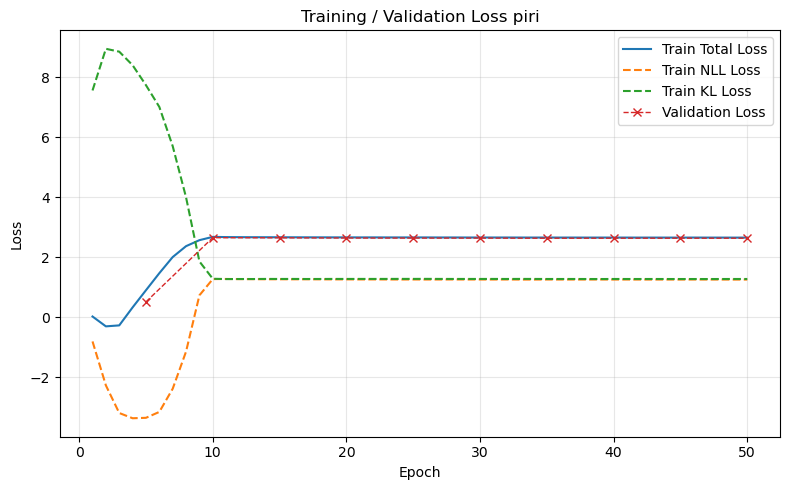

In [120]:
epochs_range = range(1, len(train_total_losses) + 1)

plt.figure(figsize=(8,5))
plt.plot(epochs_range, train_total_losses, label='Train Total Loss')
plt.plot(epochs_range, train_nll_losses, label='Train NLL Loss', linestyle='--')
plt.plot(epochs_range, train_kl_losses, label='Train KL Loss', linestyle='--')

if len(val_total_losses) > 0:
    plt.plot(epochs_range[4::5], val_total_losses, 'x--', label='Validation Loss', linewidth=1)

plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title(f'Training / Validation Loss {conditionedOn}')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


In [121]:
valModel = CVAE(zdim=zdim, cond_type=conditionedOn).to(device)

scalers = joblib.load("normalizers/normalizers_"+conditionedOn+".pkl")
valModel.attach_normalizers(**scalers)
ckpt = torch.load("ckpts/cvae_checkpoint_"+conditionedOn+".pt", map_location="cpu", weights_only=True)
valModel.load_state_dict(ckpt['model_state'])

<All keys matched successfully>

In [135]:
def plot_r_distributions(model, r_next, c_n, n_samples=50000, device=device, Tr=1.0, Tz=1.0):
    """
    Compare benchmark, reconstructed, and generated distributions of r_{n+1}.
    
    Args:
        model: trained CVAE model with attached scalers
        c_n (np.ndarray): conditioning vectors (v_n, r_n), shape [N, c_dim]
        r_next (np.ndarray): true target auxiliary variable, shape [N, 3]
        n_samples: number of samples to draw for visualization
        device: torch device
    """
    # --- Subsample for efficiency ---
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]
    
    c_norm = torch.tensor(model.scaler_c.transform(c_s), dtype=torch.float32)
    r_next_norm = torch.tensor(model.scaler_r.transform(r_next_s), dtype=torch.float32)

    # --- Forward pass (reconstruction) ---
    model.eval()
    with torch.no_grad():
        c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
        r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)
        dec_out, q, p = model(r_next_t, c_t)
        mu_r, log_sig_r = dec_out
        r_rec_norm = mu_r.cpu().numpy()
        r_rec_norm = mu_r + torch.exp(log_sig_r) * torch.randn_like(mu_r) * Tr
        r_rec = model.scaler_r.inverse_transform(r_rec_norm.cpu())

        # --- Generated samples ---
        r_gen = model.sample(c_s, Tr=Tr, Tz=Tz)

    # --- Plot ---
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    labels = ["r_x", "r_y", "r_z"]
    colors = ["tab:blue", "tab:orange", "tab:green"]
    
    for i, ax in enumerate(axes):
        kde_bench = gaussian_kde(r_next_s[:, i])
        kde_rec = gaussian_kde(r_rec[:, i])
        kde_gen = gaussian_kde(r_gen[:, i].flatten())

        xs = np.linspace(
            min(r_next_s[:, i].min(), r_rec[:, i].min(), r_gen[:, i].min()),
            max(r_next_s[:, i].max(), r_rec[:, i].max(), r_gen[:, i].max()),
            300,
        )
        ax.plot(xs, kde_bench(xs), label="Benchmark", color=colors[i], lw=2)
        ax.plot(xs, kde_rec(xs), "--", color="black", lw=1.5, label="Reconstructed")
        ax.plot(xs, kde_gen(xs), ":", color="red", lw=1.5, label="Generated")

        ax.set_title(f"Distribution of {labels[i]}")
        ax.set_xlabel(labels[i])
        ax.set_ylabel("Density")
        ax.set_xlim(-0.05, 0.05)
        ax.legend()

    plt.tight_layout()
    plt.show()
    
    return r_next_s, r_rec, r_gen
    
def visualize_latent_distributions(model, r_next, c_n, n_samples=50000, device=device):
    """
    Visualize latent space distributions for encoder vs conditional prior.

    Args:
        model: trained CVAE
        c_n (np.ndarray): conditioning variables (r_n, v_n)
        r_next (np.ndarray): true target variables (r_{n+1})
        n_samples (int): number of samples to analyze
        device: torch device
    """
    N = len(c_n)
    idx = np.random.choice(N, size=min(n_samples, N), replace=False)
    c_s = c_n[idx]
    r_next_s = r_next[idx]

    # Normalize
    c_norm = torch.tensor(model.scaler_c.transform(c_s), dtype=torch.float32, device=device)
    r_next_norm = torch.tensor(model.scaler_r.transform(r_next_s), dtype=torch.float32, device=device)

    model.eval()
    with torch.no_grad():
        _, (q_mu, q_logv), _ = model(r_next_norm, c_norm)
        p_mu, p_logv = model.prior_params(c_norm)
        q_mu, q_logv = q_mu.cpu().numpy(), q_logv.cpu().numpy()
        p_mu, p_logv = p_mu.cpu().numpy(), p_logv.cpu().numpy()

    q_std = np.exp(0.5 * q_logv)
    p_std = np.exp(0.5 * p_logv)

    zdim = q_mu.shape[1]

    # --- Plot histograms of latent means ---
    fig, axes = plt.subplots(2, zdim, figsize=(4*zdim, 6))
    for i in range(zdim):
        ax = axes[0, i]
        ax.hist(q_mu[:, i], bins=50, alpha=0.6, label="Encoder μ_q", color="tab:blue")
        ax.hist(p_mu[:, i], bins=50, alpha=0.6, label="Prior μ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: means")
        ax.legend()

        ax = axes[1, i]
        ax.hist(q_std[:, i], bins=50, alpha=0.6, label="Encoder σ_q", color="tab:blue")
        ax.hist(p_std[:, i], bins=50, alpha=0.6, label="Prior σ_p", color="tab:orange")
        ax.set_title(f"Latent dim {i}: stds")
        ax.legend()

    plt.tight_layout()
    plt.show()

In [136]:
val_loader_full = DataLoader(val_ds, batch_size=8192, shuffle=False)
all_r, all_c = [], []

for r_win, c_win in val_loader_full:
    r_flat = r_win.reshape(-1, r_win.shape[-1])
    c_flat = c_win.reshape(-1, c_win.shape[-1])
    all_r.append(r_flat)
    all_c.append(c_flat)

r_next_val = torch.cat(all_r, dim=0)
c_val = torch.cat(all_c, dim=0)

r_val_ph = valModel.scaler_r.inverse_transform(r_next_val)
c_val_ph = valModel.scaler_c.inverse_transform(c_val)

/tmp/ipykernel_1141293/3822227927.py:24: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  c_t = torch.tensor(c_norm, dtype=torch.float32, device=device)
/tmp/ipykernel_1141293/3822227927.py:25: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  r_next_t = torch.tensor(r_next_norm, dtype=torch.float32, device=device)


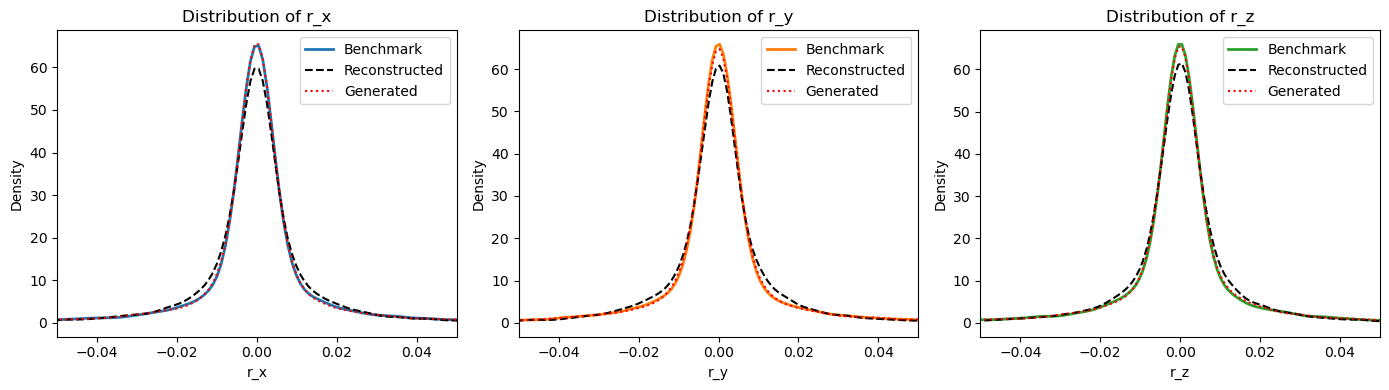

In [141]:
# Assume you have:
# r_n, v_n, r_next = benchmark arrays (each [N,3])
# model = trained CVAE with attached scalers

r_bench, r_rec, r_gen = plot_r_distributions(valModel, r_val_ph, c_val_ph, n_samples=20000, Tr=1, Tz=1)

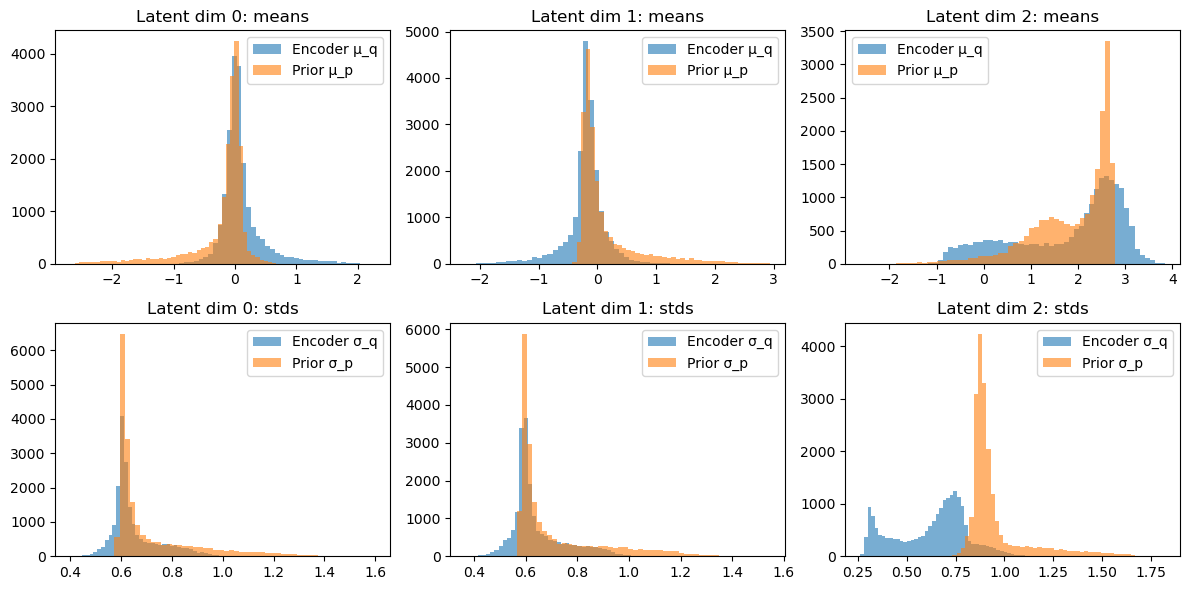

In [125]:
# Assuming you have arrays from benchmark data
# r_n, v_n, r_next -> each [N, 3]
visualize_latent_distributions(valModel, r_val_ph, c_val_ph, n_samples=20000)

In [126]:
batch = next(iter(val_loader))
r_nxt_b, c_t = [x.to(device) for x in batch]

with torch.no_grad():
    dec_out, (q_mu,q_logv), (p_mu,p_logv) = valModel(r_nxt_b, c_t)
    q_std = torch.exp(0.5*q_logv).mean().item()
    p_std = torch.exp(0.5*p_logv).mean().item()
    mu_r, log_sig_r = dec_out
    r_std = torch.exp(log_sig_r).mean().item()
print(f"mean q_std={q_std:.3f}  p_std={p_std:.3f}  decoder_sigma={r_std:.3f}")

mean q_std=0.639  p_std=0.788  decoder_sigma=0.491


In [127]:
def stats(x): 
    x = x.detach().cpu().numpy().reshape(-1)
    qs = np.quantile(x, [0.1,0.5,0.9])
    return f"mean={x.mean():.3f} q10={qs[0]:.3f} q50={qs[1]:.3f} q90={qs[2]:.3f}"
print("p_std:", stats(torch.exp(0.5*p_logv)))
print("q_std:", stats(torch.exp(0.5*q_logv)))
print("dec σ:", stats(torch.exp(log_sig_r)))

p_std: mean=0.788 q10=0.597 q50=0.753 q90=1.019
q_std: mean=0.639 q10=0.501 q50=0.618 q90=0.805
dec σ: mean=0.491 q10=0.185 q50=0.311 q90=1.110
